# Titanic EDA
Exploratory Data Analysis of the Titanic dataset.
Goal: Understand the data before cleaning and feature engineering.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (8, 4)

df = pd.read_csv('Titanic-Dataset.csv')
print('Shape:', df.shape)

Shape: (891, 12)


## 1. Data Overview

In [25]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [27]:
df.describe() # getting statictial insights

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 📌 What I Understand from `df.describe()`

| Column | Key Insight |
|---|---|
| `PassengerId` | Ranges 1–891, mean=446 — just a row ID, **no predictive value → drop it** |
| `Survived` | mean=0.38 → only **38% survived** — dataset is imbalanced (62% did not survive) |
| `Pclass` | median=3 → **majority were 3rd class** passengers |
| `Age` | count=714 out of 891 → **177 missing values (~20%)** — needs imputation; range 0.42–80 yrs |
| `SibSp` | median=0, mean=0.52 → **most passengers had no siblings/spouse** on board |
| `Parch` | median=0, 75th percentile=0 → **most had no parents/children** — mostly solo travellers |
| `Fare` | mean(32.2) >> median(14.45) → **right-skewed**; min=0 (suspicious rows) → needs log transform |

**Actions to take next:**
- Fill 177 missing `Age` values → use median age per `Pclass` group
- Investigate `Fare = 0` rows — could be errors or crew
- Apply `np.log1p(Fare)` before modelling to fix the right skew
- Create `FamilySize = SibSp + Parch + 1` and `IsAlone` binary flag
- Drop `PassengerId` — it's just a sequential row number

In [28]:
df.describe(include='object') # for unique values

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [29]:
'Duplicate rows:', df.duplicated().sum() # checking duplicates rows

('Duplicate rows:', np.int64(0))

**What I understand from Data Overview:**
- `df.head()` shows the first 5 rows — I can see the column names, data types at a glance, and spot obvious issues (like missing Cabin values)
- `df.info()` tells me which columns have missing data (`Age`: 714 non-null, `Cabin`: 204 non-null, `Embarked`: 889 non-null) and the data type of each column
- `df.describe()` gives statistical insight — `Age` mean (~30) and median (~28) are close so Age is roughly normally distributed; `Fare` mean (32) >> median (14) so Fare is right-skewed
- `df.describe(include='object')` shows categorical columns — `Sex` has 2 unique values, `Embarked` has 3, `Cabin` has 147 unique values (very high, confirms it's hard to use directly)
- `duplicated().sum() = 0` — no duplicate rows, so no cleaning needed here

## 2. Missing Value Analysis

In [30]:
missing = df.isnull().sum() # getting missing value count
missing_pct = (missing / len(df) * 100).round(2) # convert into percentage
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0') # convert into dataframe for displaying

,Missing Count,Missing %
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


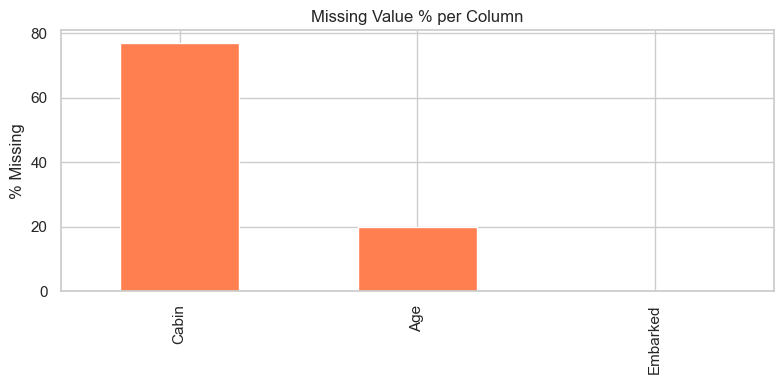

In [31]:
missing_pct.drop(missing_pct[missing_pct == 0].index).sort_values(ascending=False).plot(
    kind='bar', color='coral', title='Missing Value % per Column'
)
plt.ylabel('% Missing')
plt.tight_layout()
plt.show()

In [32]:
print('Age missing by Pclass:')
print(df[df['Age'].isnull()]['Pclass'].value_counts())
print('\nCabin missing by Pclass:')
print(df[df['Cabin'].isnull()]['Pclass'].value_counts())

Age missing by Pclass:
Pclass
3    136
1     30
2     11
Name: count, dtype: int64

Cabin missing by Pclass:
Pclass
3    479
2    168
1     40
Name: count, dtype: int64


**What I understand from Missing Value Analysis:**
- **`Cabin`** is 77% missing — too much to fill reliably. Best approach: drop it OR create a binary `HasCabin` column (1 if not null, 0 if null)
- **`Age`** is ~20% missing — fillable. Since the bar chart shows Age is the second most missing column, I should fill it using the **median age per Pclass** (not a global median) because different classes had different age profiles
- **`Embarked`** is only 0.22% missing (just 2 rows) — trivially easy to fix, fill with the mode ('S')
- The 'missing by Pclass' output shows Age is missing more in **3rd class** — so the missingness is not random (MAR), which confirms I should use grouped imputation not a global fill

## 3. Target Variable — Survived

Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate: 38.379999999999995 %


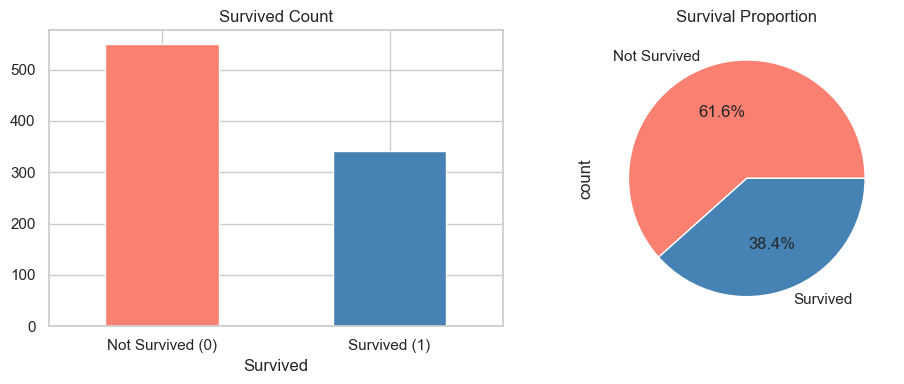

In [33]:
print(df['Survived'].value_counts())
print('\nSurvival Rate:', df['Survived'].mean().round(4) * 100, '%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['salmon','steelblue'],
                                   title='Survived Count')
axes[0].set_xticklabels(['Not Survived (0)', 'Survived (1)'], rotation=0)
df['Survived'].value_counts().plot(kind='pie', ax=axes[1], labels=['Not Survived','Survived'],
                                   autopct='%1.1f%%', colors=['salmon','steelblue'],
                                   title='Survival Proportion')
plt.tight_layout()
plt.show()

**What I understand from Target Variable Analysis:**
- Only **38% survived** — this is an imbalanced dataset (62% did not survive)
- The pie chart makes this immediately visible — more than half the pie is the 'Not Survived' slice
- Because the dataset is imbalanced, a model that always predicts 'Not Survived' would get ~62% accuracy without learning anything useful
- **Implication for modelling:** I should use **F1-Score, Precision, and Recall** alongside accuracy to properly evaluate model performance

## 4. Categorical Features vs Survival

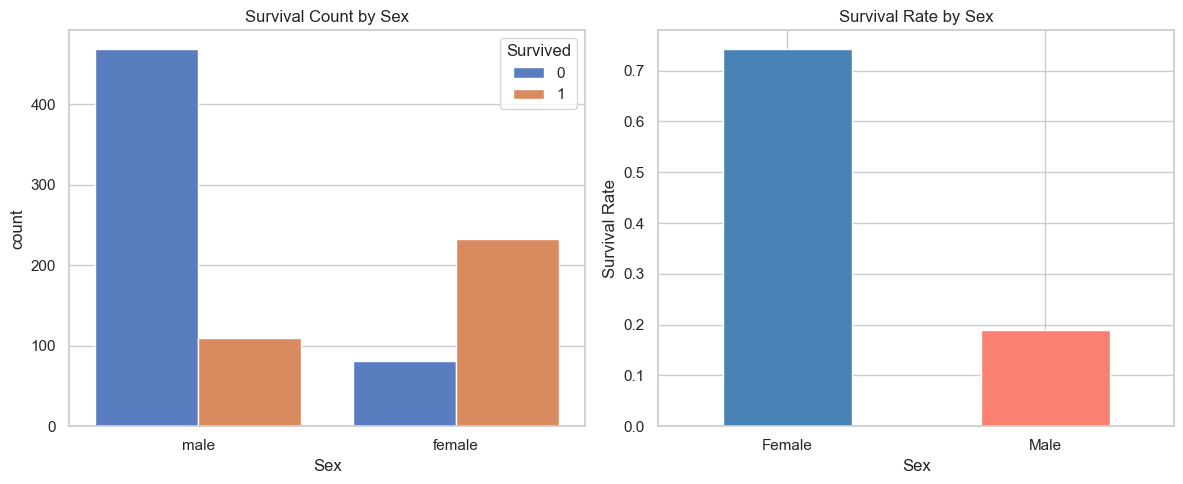

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0])
axes[0].set_title('Survival Count by Sex')
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['steelblue','salmon'])
axes[1].set_title('Survival Rate by Sex')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
plt.tight_layout()
plt.show()

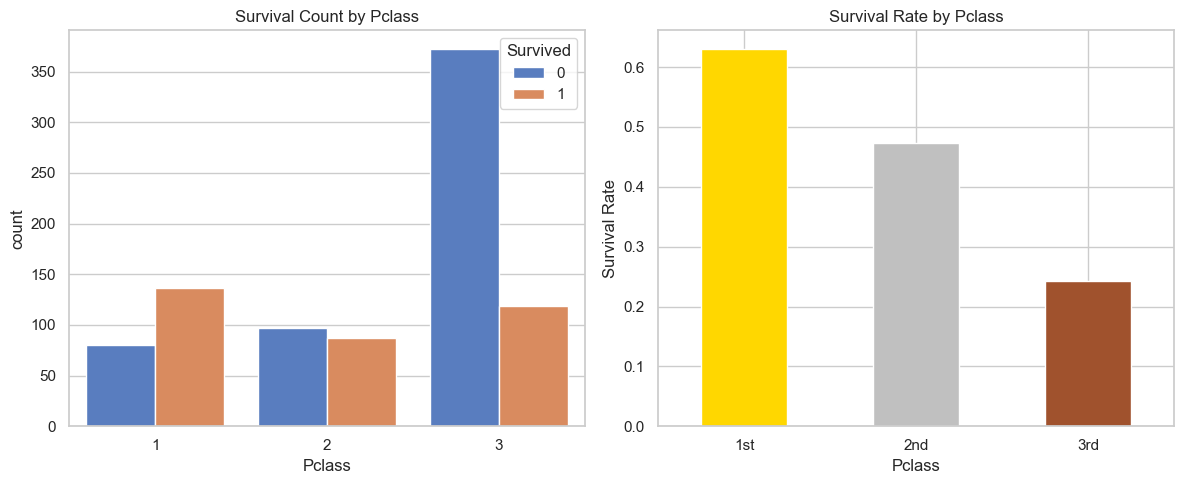

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0])
axes[0].set_title('Survival Count by Pclass')
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['gold','silver','sienna'])
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
plt.tight_layout()
plt.show()

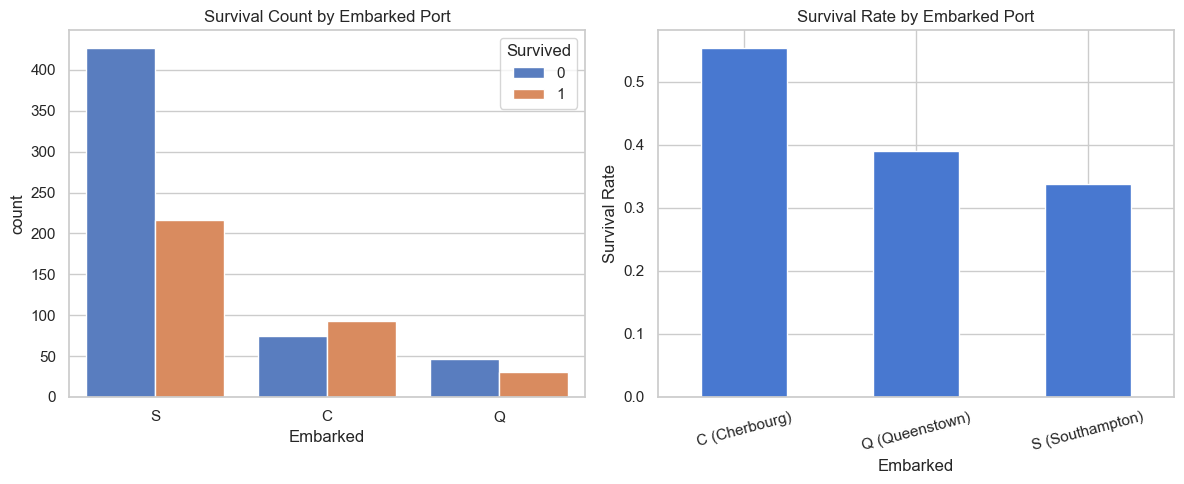

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Embarked', hue='Survived', data=df, ax=axes[0])
axes[0].set_title('Survival Count by Embarked Port')
df.groupby('Embarked')['Survived'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Survival Rate by Embarked Port')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['C (Cherbourg)', 'Q (Queenstown)', 'S (Southampton)'], rotation=15)
plt.tight_layout()
plt.show()

Survival Rate by Sex + Pclass:
 Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


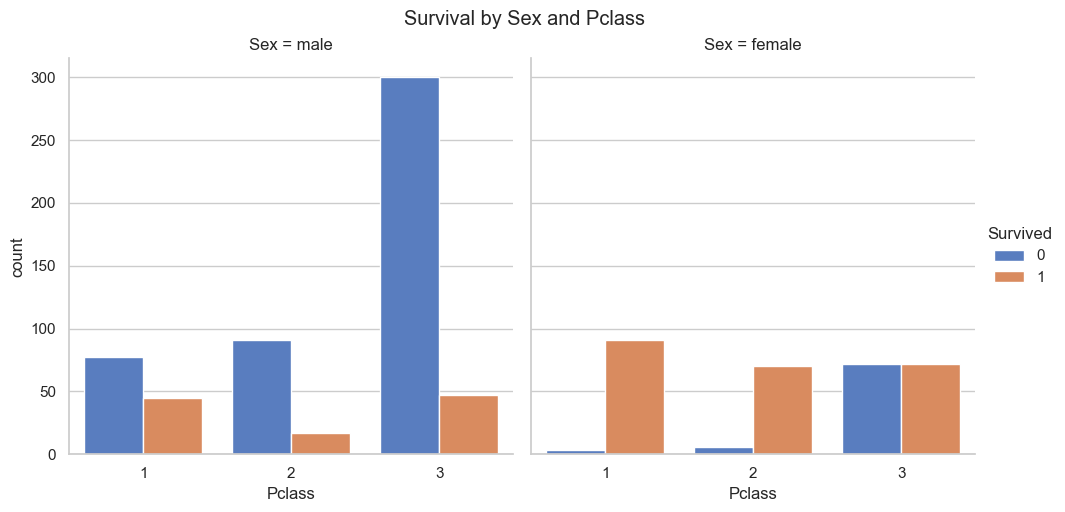

In [37]:
pivot = df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
print('Survival Rate by Sex + Pclass:\n', pivot)

sns.catplot(x='Pclass', hue='Survived', col='Sex', data=df, kind='count', height=5)
plt.suptitle('Survival by Sex and Pclass', y=1.02)
plt.show()

**What I understand from Categorical Features vs Survival:**
- **Sex** is the strongest single predictor: females survived at ~74%, males at only ~19%. The count plot shows most survivors in the female group
- **Pclass** clearly matters: 1st class bar is tallest in the survival=1 group. The survival rate bar chart confirms: 1st class ~63%, 2nd ~47%, 3rd ~24%
- **Embarked** has a pattern: Cherbourg (C) passengers survived more — but this is likely because more wealthy 1st class passengers boarded at Cherbourg
- **Sex + Pclass combined** is the most powerful chart: 1st class females had ~97% survival, 3rd class males had ~15%. The 'women and children first' rule is clearly visible
- **Insight:** Sex and Pclass together explain most of the survival pattern — they are the most important features

## 5. Numerical Features Analysis

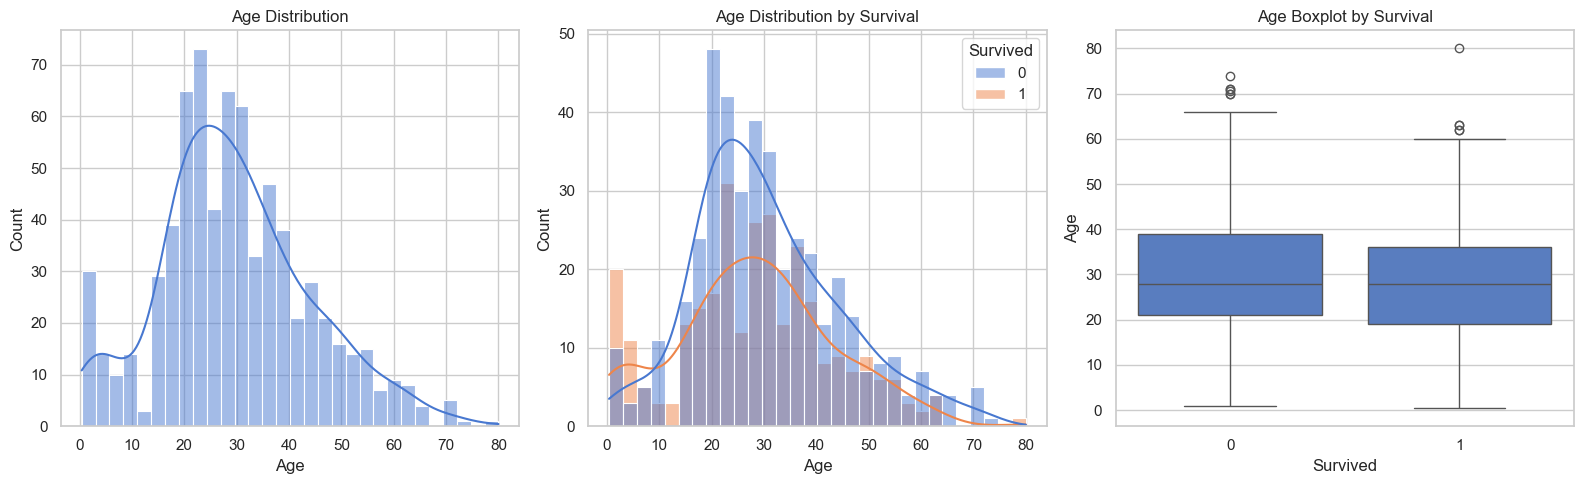

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(data=df.dropna(subset=['Age']), x='Age', hue='Survived', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Age Distribution by Survival')

sns.boxplot(x='Survived', y='Age', data=df, ax=axes[2])
axes[2].set_title('Age Boxplot by Survival')
plt.tight_layout()
plt.show()

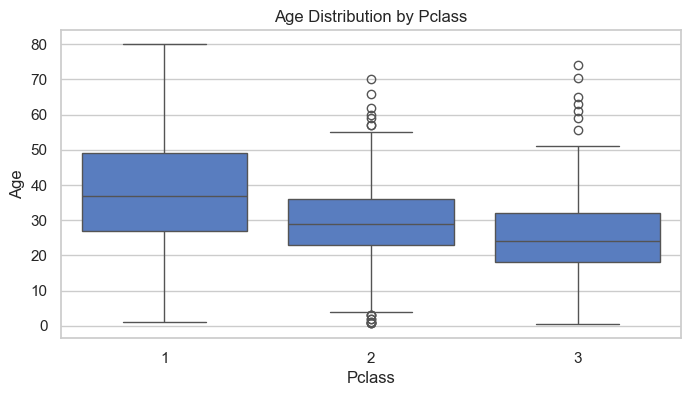

Median Age by Pclass:
Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64


In [39]:
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Age Distribution by Pclass')
plt.show()
print('Median Age by Pclass:')
print(df.groupby('Pclass')['Age'].median())

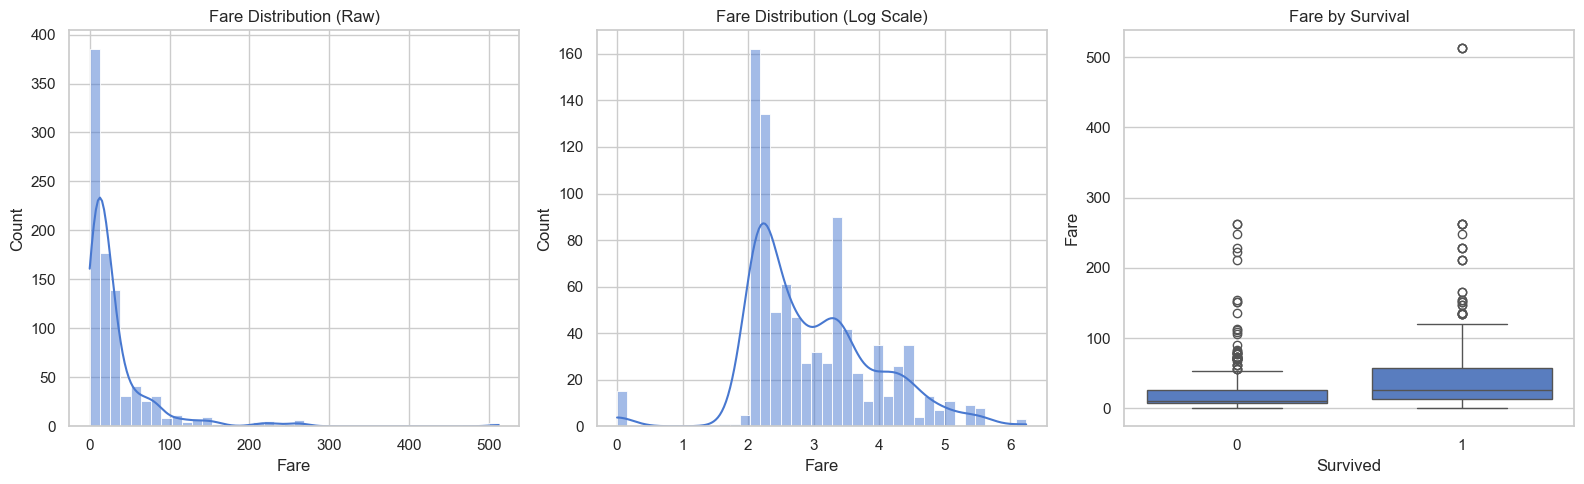

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(df['Fare'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Fare Distribution (Raw)')

sns.histplot(np.log1p(df['Fare']), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Fare Distribution (Log Scale)')

sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[2])
axes[2].set_title('Fare by Survival')
plt.tight_layout()
plt.show()

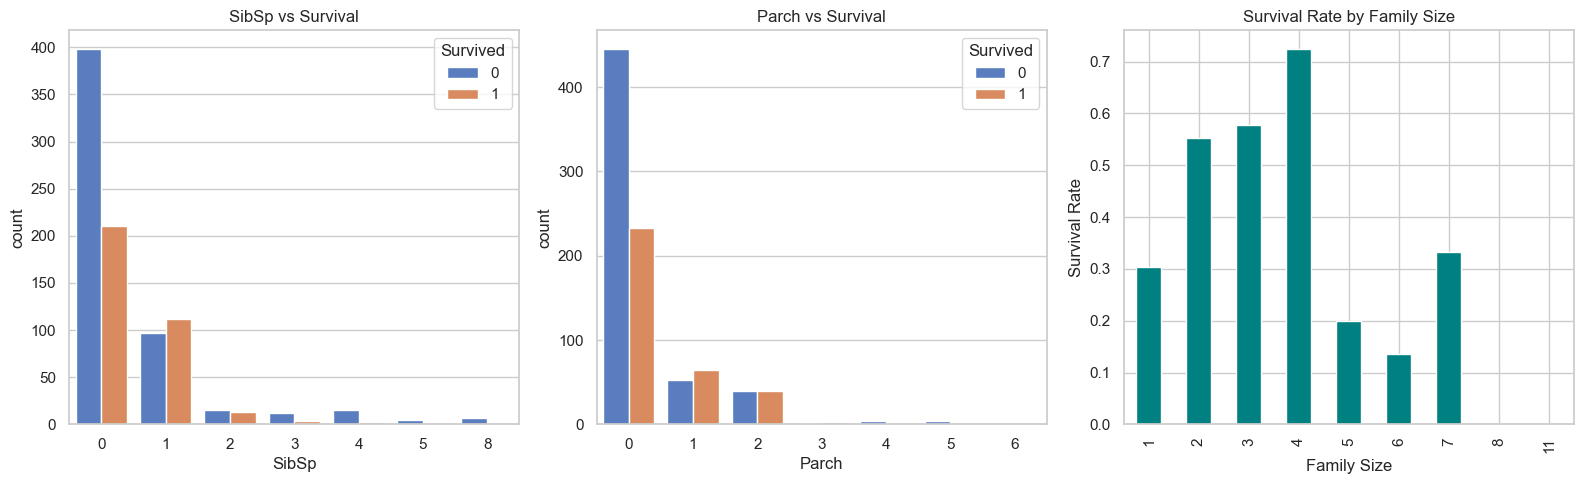

In [41]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.countplot(x='SibSp', hue='Survived', data=df, ax=axes[0])
axes[0].set_title('SibSp vs Survival')

sns.countplot(x='Parch', hue='Survived', data=df, ax=axes[1])
axes[1].set_title('Parch vs Survival')

family_surv = df.groupby('FamilySize')['Survived'].mean()
family_surv.plot(kind='bar', ax=axes[2], color='teal')
axes[2].set_title('Survival Rate by Family Size')
axes[2].set_ylabel('Survival Rate')
axes[2].set_xlabel('Family Size')
plt.tight_layout()
plt.show()

**What I understand from Numerical Features Analysis:**
- **Age distribution:** The histogram shows most passengers were between 20–40 years old. The 'Age by Survival' histogram shows children (left side) had higher survival — the 'women and children first' rule is visible here too
- **Age by Pclass boxplot:** 1st class passengers were older (median ~37), 3rd class were younger (median ~25). This confirms I should fill missing Age using **median per Pclass**, not a global median
- **Fare distribution:** The raw histogram has a very long right tail (a few extremely expensive tickets) — this is right skew. The log-scale histogram looks much more normal. The 'Fare by Survival' boxplot shows survivors paid higher fares on average
- **FamilySize:** The survival rate bar chart shows a clear pattern — solo travellers (size=1) and very large families (5+) survived less. Families of size 2–4 had the best survival rate. This makes `FamilySize` a useful feature

## 6. Correlation Heatmap

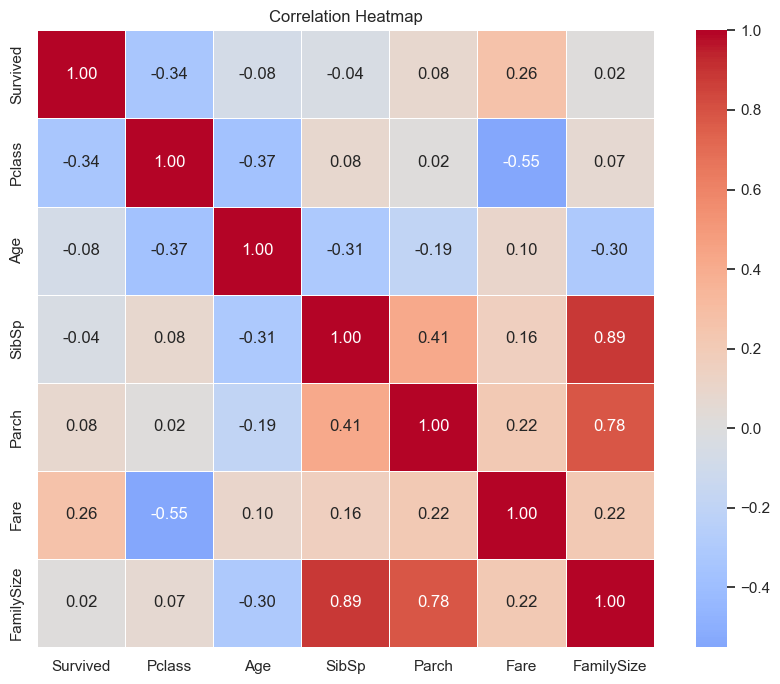

In [42]:
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**What I understand from the Correlation Heatmap:**
- **`Pclass` vs `Survived`**: negative correlation (~-0.34) — lower class number (richer) = more likely to survive
- **`Fare` vs `Survived`**: positive correlation (~+0.26) — higher fare = more likely to survive (because fare and class are linked)
- **`Fare` vs `Pclass`**: strong negative correlation (~-0.55) — these two features carry overlapping information. Using both in a model may cause **multicollinearity**
- **`SibSp`, `Parch`, `FamilySize`**: all positively correlated with each other — using all three is redundant. `FamilySize` alone captures the family information
- **`Age` vs `Survived`**: weak negative correlation (~-0.07) — older passengers slightly less likely to survive, but Age alone is not a strong predictor

## 7. Advanced EDA — Title Extraction & Age Binning

Title Value Counts:
 Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


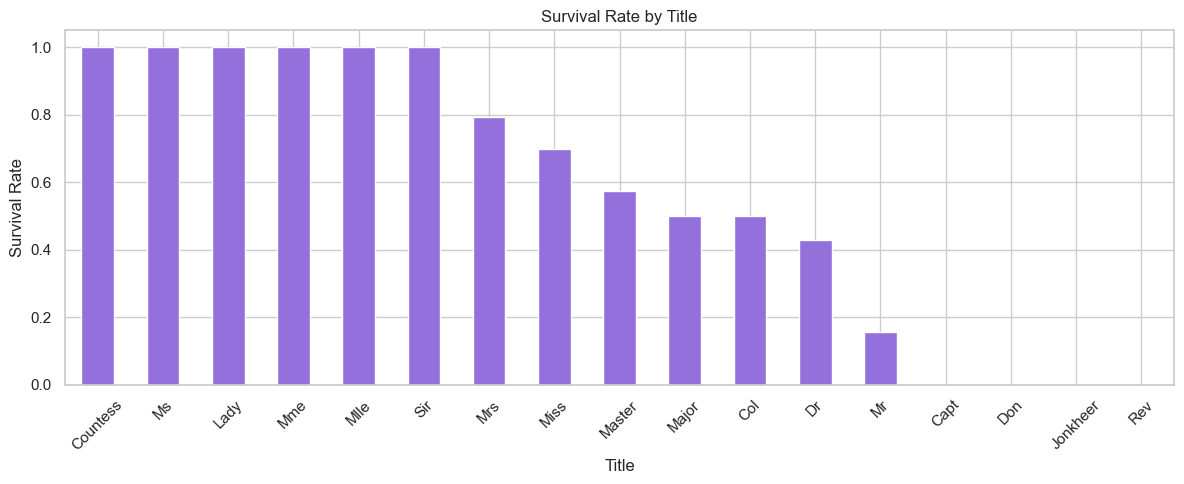

In [43]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
print('Title Value Counts:\n', df['Title'].value_counts())

title_surv = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
title_surv.plot(kind='bar', figsize=(12, 5), color='mediumpurple',
                title='Survival Rate by Title')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

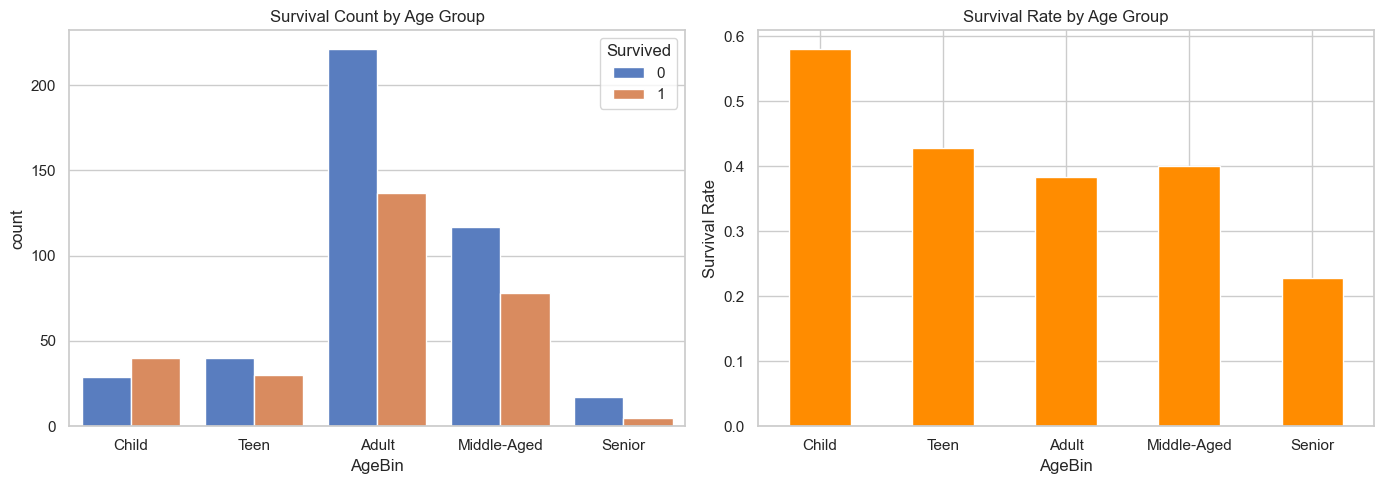

In [44]:
df['AgeBin'] = pd.cut(df['Age'],
                      bins=[0, 12, 18, 35, 60, 100],
                      labels=['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='AgeBin', hue='Survived', data=df, ax=axes[0])
axes[0].set_title('Survival Count by Age Group')

df.groupby('AgeBin', observed=True)['Survived'].mean().plot(
    kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Survival Rate by Age Group')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**What I understand from Advanced EDA (Title & Age Bins):**
- **Title extraction:** The most common title is 'Mr' (~517), followed by 'Miss' (~182) and 'Mrs' (~125). Rare titles like 'Rev', 'Dr', 'Col' can be grouped into an 'Other' category
- **Title vs Survival:** The bar chart shows 'Mrs' and 'Miss' had very high survival, 'Master' (young boys) also had high survival, while 'Mr' had the lowest survival rate — confirming gender and age patterns
- **Title is a powerful engineered feature** because it captures both gender and social status in one variable
- **Age bins:** The count plot shows 'Adult' (18–35) was the largest group. The survival rate chart shows 'Child' (0–12) had the highest survival rate, followed by females — confirming children were prioritised
- Age binning is useful because the survival effect of age is **non-linear** (children vs adults matters more than exact age)

## 8. Pairplot — Big Picture View

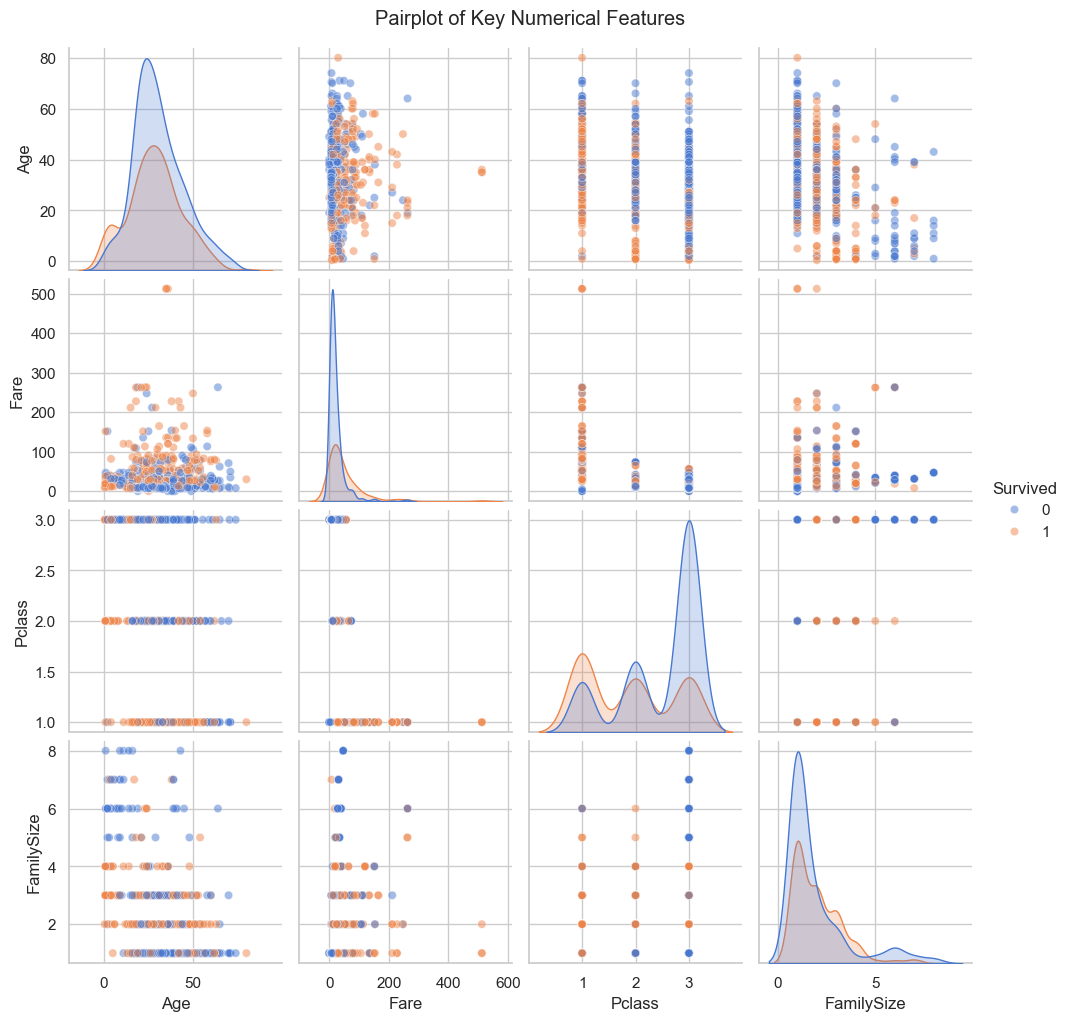

In [45]:
pair_cols = ['Survived', 'Age', 'Fare', 'Pclass', 'FamilySize']
sns.pairplot(df[pair_cols].dropna(), hue='Survived', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Key Numerical Features', y=1.02)
plt.show()

**What I understand from the Pairplot:**
- The pairplot gives a **big picture view** of how all numerical features relate to each other and to survival (colour-coded: orange = survived, blue = not survived)
- **Fare vs Pclass:** The scatter plot shows a clear cluster pattern — low Pclass + high Fare = survivors. This confirms the class-fare connection
- **Age vs Fare:** Survivors (orange) tend to cluster at higher Fare values regardless of age — Fare is a stronger survival signal than Age alone
- **Diagonal (KDE plots):** The orange and blue distributions for `Fare` and `Pclass` are most separated — confirming these are the most discriminative features
- **Limitation:** Pairplot is slow and only shows numerical columns. It does not include Sex or Embarked — those were better analysed separately

## 9. EDA Summary — Key Findings

| Feature | Finding |
|---|---|
| **Sex** | Females survived at ~74% vs males at ~19% |
| **Pclass** | 1st class: ~63% survived, 3rd class: ~24% |
| **Age** | Children had higher survival; age partially missing |
| **Fare** | Higher fare → higher survival (correlated with Pclass) |
| **FamilySize** | Solo travelers and large families (>4) fared worse |
| **Embarked** | Cherbourg (C) had highest survival rate |
| **Title** | Miss/Mrs/Master had much higher survival than Mr |
| **Missing** | Age: 20% missing (fill by Pclass median), Cabin: 77% missing (create binary flag) |

---
## What I Understand After Doing EDA

### 1. About the Data
- The dataset has **891 rows and 12 columns**
- **3 columns have missing values:** `Age` (177 missing, ~20%), `Cabin` (687 missing, ~77%), `Embarked` (2 missing)
- No duplicate rows exist
- `PassengerId` is just a row number — it carries **no predictive value**

---

### 2. About Survival (Target Variable)
- Only **38% of passengers survived** — the dataset is **imbalanced**
- This means accuracy alone is not a reliable metric for model evaluation — I should also look at **Precision, Recall, and F1-Score**

---

### 3. Who Survived and Who Didn't

| Factor | Finding |
|---|---|
| **Sex** | Females survived at **~74%**, males at only **~19%** — strongest single predictor |
| **Pclass** | 1st class: **~63%** survived, 2nd: **~47%**, 3rd: **~24%** — class = privilege |
| **Sex + Pclass** | 1st class females survived the most (~97%), 3rd class males survived the least (~15%) |
| **Age** | Children (age < 12) had higher survival — "women and children first" rule is visible |
| **Embarked** | Cherbourg (C) passengers survived more — likely because more 1st class boarded there |
| **FamilySize** | Solo travellers and very large families (5+) survived less — mid-size families (2–4) did better |
| **Fare** | Higher fare = higher survival — but this is mostly because fare is linked to Pclass |
| **Title** | Miss/Mrs/Master had much higher survival than Mr — confirms gender and age pattern |

---

### 4. About the Features — What Needs to Be Fixed

| Column | Problem | Plan |
|---|---|---|
| `Age` | 177 missing values (~20%) | Fill with **median age per Pclass group** |
| `Cabin` | 687 missing values (~77%) | Drop column OR create binary flag: `HasCabin` (1/0) |
| `Embarked` | 2 missing values | Fill with **mode** (most frequent port = 'S') |
| `Fare` | Right-skewed (mean >> median), min=0 | Apply `log1p` transform; investigate Fare=0 rows |
| `PassengerId` | Just a row ID | **Drop it** |
| `Ticket` | Unstructured text, hard to use | **Drop it** |
| `Name` | Raw text — but Title can be extracted | Extract Title, then drop Name |

---

### 5. New Features I Should Create (Feature Engineering Ideas)

| New Feature | How to Create | Why Useful |
|---|---|---|
| `FamilySize` | `SibSp + Parch + 1` | Better than using SibSp and Parch separately |
| `IsAlone` | `1 if FamilySize == 1 else 0` | Solo travellers had lower survival |
| `Title` | Extract from `Name` using regex | Captures gender + social status in one feature |
| `HasCabin` | `1 if Cabin is not null else 0` | Cabin presence correlates with 1st class |
| `AgeBin` | Cut Age into groups (Child/Teen/Adult/Senior) | Captures non-linear age effect |
| `LogFare` | `np.log1p(Fare)` | Fixes right skew before modelling |

---

### 6. Correlations I Observed
- `Fare` and `Pclass` are **strongly correlated** (higher class = higher fare) — avoid using both directly
- `SibSp`, `Parch`, and `FamilySize` are naturally related — use `FamilySize` instead of all three
- `Survived` correlates most strongly with: **Sex > Pclass > Fare > Age**

---

### 7. Next Steps
1. **`02_data_cleaning.ipynb`** — Handle missing values, fix skew, drop useless columns
2. **`03_feature_engineering.ipynb`** — Create new features (FamilySize, IsAlone, Title, HasCabin)
3. **`04_model_training.ipynb`** — Train and evaluate ML models on the cleaned data